## Notebook to compare single neuron morphologies with MAPseq dataset
Start by establishing dataframe

In [1]:
from pathlib import Path
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
import lc_reconstruction_analysis.utils as utils
import lc_reconstruction_analysis.dendritic as dendritic
import lc_reconstruction_analysis.clustering as clustering
import lc_reconstruction_analysis.axon as axon
import lc_reconstruction_analysis.correlation as correlation
%matplotlib inline

In [2]:
# Define path to data
DATA_DIR = Path("/data/")
# Load data frame of cells, and networkx graphs
dataDF, graphs = utils.load_cells(DATA_DIR)

Missing structure dendrite for /data/685221_12_5_24/Complete_annotated/N064-68221-JN.json
Missing structure dendrite for /data/685221_12_5_24/Complete_annotated/N025-685221-PG.json
Missing structure axon for /data/685221_12_5_24/Complete_annotated/N064-685221-JN.json
Missing structure dendrite for /data/685221_12_5_24/Complete_annotated/N051-685221 -YP.json
Missing structure dendrite for /data/648434_12_5_24/Complete_annotated/N024-648434-SS.json
Error finding structures for: N025-685221-PG, dropping from dataframe
Error finding structures for: N064-68221-JN, dropping from dataframe
Error finding structures for: N064-685221-JN, dropping from dataframe
Error finding structures for: N051-685221 -YP, dropping from dataframe
Error finding structures for: N024-648434-SS, dropping from dataframe


In [3]:
# Exclude any neurons that need to be excluded
excludeList = [ # Look like MY cells mistakenly included in LC batch
    "N039-685222-AK",
    "N040-685222-VM",
    "N066-685221-JN",
    "N068-685221-HD",
    "N067-685221-HS"
]

dataDF = dataDF.drop(dataDF[dataDF["Graph"].isin(excludeList)].index)

In [4]:
# Load data
df = clustering.build_length_df(dataDF, graphs, DATA_DIR, normalize_df=False)
df = df.drop(list(set(df.index) - set(dataDF["Graph"]))) # Drop graphs not included in dataDF
# Normalize length within each neuron
dfNorm = df.copy()
dfNorm = dfNorm.divide(dfNorm.sum(axis=1),axis=0)
# Merge dataframes
sorted_columns = ["OLF","Isocortex","HPF","CTXsp","CNU","TH","HY","MB","CB","P","MY","Other"]
plotDF = dataDF.copy().merge(dfNorm[sorted_columns], left_on="Graph", right_index = True)

In [5]:
# Add total length
plotDF = plotDF.merge(pd.Series(df.sum(axis=1) / 1e4 , name = "Total Length (cm)"), left_on="Graph",right_index = True) # convert from microns to centimeters
plotDF["Norm Length"] = plotDF["Total Length (cm)"] / plotDF["Total Length (cm)"].max()

# Compute total axonal branches
axon_branch_dict = {}
for name in plotDF["Graph"]:
    graph = graphs[name]
    axon_branch_nodes = [node for node in graph.nodes() if graph.out_degree(node) > 1 and graph.nodes[node]["structure_id"] == 2]
    axon_branch_dict[name] = len(axon_branch_nodes)

# Add axonal branches to dataframe
plotDF = plotDF.merge(pd.Series(axon_branch_dict, name = "Axon Branches"), left_on = "Graph", right_index = True)
plotDF["Norm Branches"] = plotDF["Axon Branches"] / plotDF["Axon Branches"].max()

In [6]:
plotDF.head(3)

,Graph,ID,Sample,Annotator,Genotype,somaAP,somaDV,somaML,somaOnRight,OLF,...,HY,MB,CB,P,MY,Other,Total Length (cm),Norm Length,Axon Branches,Norm Branches
0,N001-685221-PG,N001,685221,PG,Dbh-Cre-KI/wt,10201.6760,4571.1625,4612.8491,False,0.000000,...,0.020860,0.255037,0.000000,0.071944,0.338564,0.173288,14.318932,0.197319,103,0.066796
63,N001-685222-SA,N001,685222,SA,Dbh-Cre-KI/wt,10345.2172,4145.2136,4709.6842,True,0.047268,...,0.028757,0.040161,0.006982,0.004348,0.000000,0.009400,72.567420,1.000000,982,0.636835
62,N002-685222-HD,N002,685222,HD,Dbh-Cre-KI/wt,10559.8164,4318.4146,4715.9901,True,0.398272,...,0.018671,0.015920,0.004814,0.007940,0.000465,0.077648,49.870732,0.687233,809,0.524643


### Get subset of graphs within CCF bounds

In [7]:
plotDF = plotDF.sort_values("somaDV",ascending=False)
dfPlotClustered = plotDF[sorted_columns + ["Norm Length","Norm Branches"]]
# dfPlotClustered = plotDF[sorted_columns + ["Norm Length"]]
plotFeature = plotDF["somaDV"].copy()
plotFeature = plotFeature.clip(4200,5000)

scaler = StandardScaler(with_mean=True)
X_scaled = scaler.fit_transform(dfPlotClustered)
# X_scaled = dfPlotClustered

# Perform PCA mapping
pca = PCA(n_components=8, random_state=0)
pca_result = pca.fit_transform(X_scaled)
# pca = TSNE(n_components=2, random_state=0)
# pca_result = pca.fit_transform(dfPlotClustered)

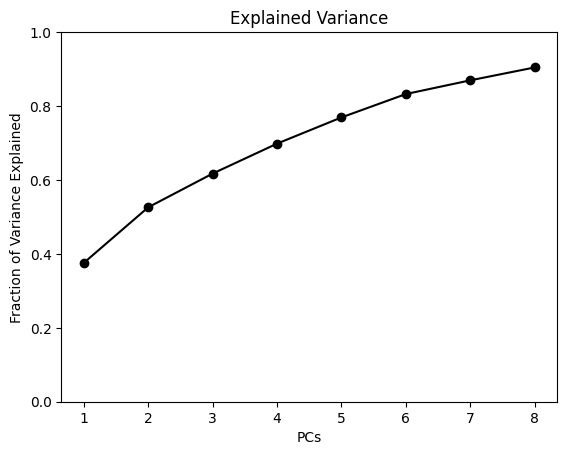

In [8]:
cumulative_variance = np.cumsum(pca.explained_variance_ratio_)
plt.plot(np.arange(len(cumulative_variance)) + 1, cumulative_variance,'o-k')
plt.ylim([0, 1])
plt.title("Explained Variance")
plt.ylabel("Fraction of Variance Explained")
plt.xlabel("PCs")
plt.savefig("../results/PCA Explained Variance.png",dpi=300, bbox_inches='tight', transparent=True)
# plt.plot(np.cumsum(pca.explained_variance_ratio_))

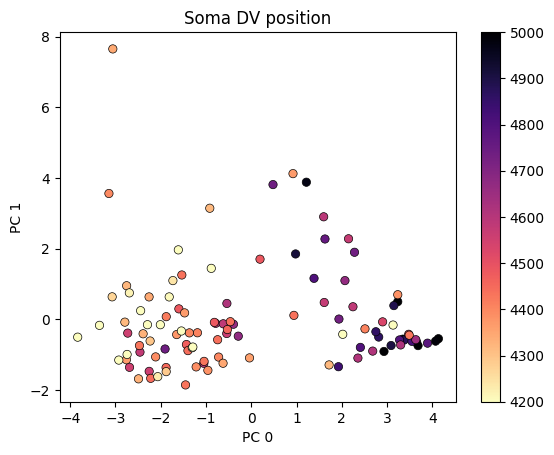

In [9]:
# Plot
i = 0
j = 1
scatter = sns.scatterplot(x = pca_result[:, i], y = pca_result[:, j], c = plotFeature, cmap = 'magma_r', edgecolor = 'k')
plt.colorbar(scatter.get_children()[0])
plt.title("Soma DV position")
plt.xlabel(f"PC {i}")
plt.ylabel(f"PC {j}")
plt.savefig(f"../results/PCs {i} and {j} colored by soma position.png",dpi=300, bbox_inches='tight', transparent = True)

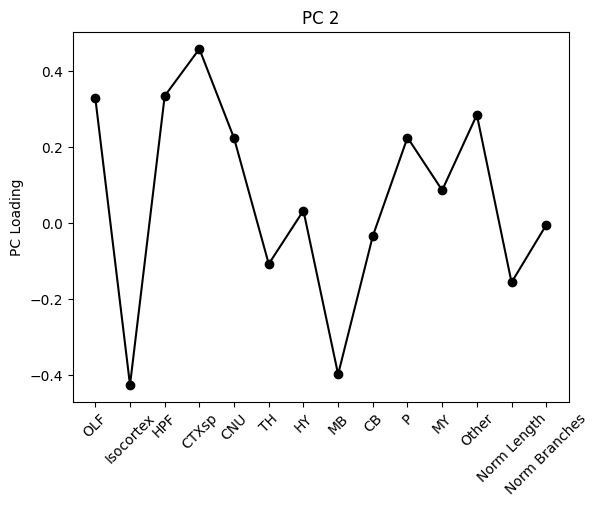

In [10]:
i = 2
plt.plot(dfPlotClustered.columns,pca.components_[i],'o-k')
plt.title(f"PC {i}")
plt.ylabel(f"PC Loading")
plt.xticks(rotation=45);
plt.savefig(f"../results/PCs {i} loading.png",dpi=300, bbox_inches='tight', transparent = True)

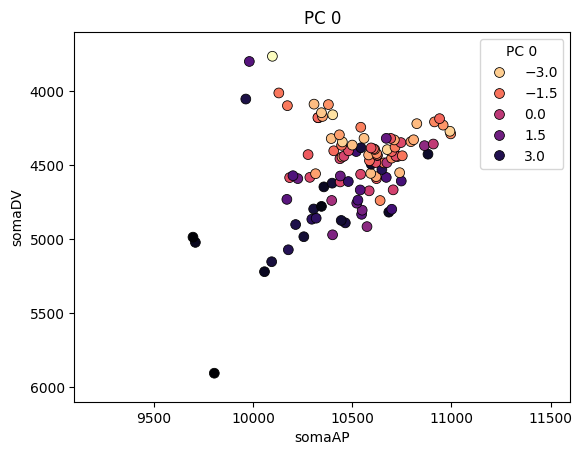

In [11]:
i = 0
cmap = sns.color_palette("magma_r", as_cmap=True)
ax = sns.scatterplot(plotDF, x = "somaAP", y = "somaDV", hue = pca_result[:, i], palette = cmap, s = 50, edgecolor = 'k')
plt.xlim([9100, 11600])
plt.ylim([3600, 6100])
ax.invert_yaxis()
plt.legend(title = f'PC {i}')
plt.title(f'PC {i}')
plt.savefig(f"../results/soma position colored by PC {i}.png",dpi=300,bbox_inches='tight', transparent= True)

In [20]:
plotDF["Top Projection"] = plotDF[sorted_columns].idxmax(axis=1).values

In [22]:
plotDF[["Graph","somaAP","somaDV","somaML"] + sorted_columns + ["Total Length (cm)", "Axon Branches","Top Projection"]].to_csv("../results/LC Morphology Summary.csv")